In [3]:
import copy
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/output2.csv")

df["sellingprice"] = pd.to_numeric(df["sellingprice"], errors="coerce")

warnings.filterwarnings("ignore", category=ConvergenceWarning)


n_1pct = max(1, int(np.ceil(len(df) * 0.01)))

lowest_1pct = df.nsmallest(n_1pct, "sellingprice").copy()
top_1pct = df.nlargest(n_1pct, "sellingprice").copy()

print(f"Total cars: {len(df)}")
print(f"1% of dataset: {n_1pct} cars")


Mounted at /content/drive
Total cars: 67125
1% of dataset: 672 cars


===== IQR Method =====
Q1: 7200.0
Q3: 21000.0
IQR: 13800.0
Lower bound: -13500.0
Upper bound: 41700.0
Number of outliers: 1779

Sample outliers:
       sellingprice  year           make                          model
4918        81000.0  2004        ferrari                            360
10694      117500.0  2007        ferrari                           f430
11977       95500.0  2007        ferrari                           f430
15192      117000.0  2008        ferrari                           f430
19208       96000.0  2010        bentley           continental gt speed
20670      101000.0  2010        bentley        continental supersports
21564      111000.0  2011        bentley          continental gtc speed
21709       47600.0  2011       infiniti                           qx56
21813       44200.0  2011       infiniti                           qx56
21928       41750.0  2011       infiniti                           qx56
21934      117800.0  2011  mercedes-benz                       

In [6]:


mean_price = df["sellingprice"].mean()
std_price = df["sellingprice"].std()

lower_std = mean_price - 3 * std_price
upper_std = mean_price + 3 * std_price

std_outliers = df[(df["sellingprice"] < lower_std) | (df["sellingprice"] > upper_std)]

print("\n===== STD Method =====")
print("Mean price:", mean_price)
print("Std:", std_price)
print("Lower bound:", lower_std)
print("Upper bound:", upper_std)

print("Number of outliers:", len(std_outliers))
print("\nSample outliers:")
print(std_outliers[["sellingprice","year","make","model"]].head(20))


===== STD Method =====
Mean price: 15694.013318435755
Std: 11353.863509394272
Lower bound: -18367.57720974706
Upper bound: 49755.60384661857
Number of outliers: 1010

Sample outliers:
       sellingprice  year           make                          model
4918        81000.0  2004        ferrari                            360
10694      117500.0  2007        ferrari                           f430
11977       95500.0  2007        ferrari                           f430
15192      117000.0  2008        ferrari                           f430
19208       96000.0  2010        bentley           continental gt speed
20670      101000.0  2010        bentley        continental supersports
21564      111000.0  2011        bentley          continental gtc speed
21934      117800.0  2011  mercedes-benz                        sls amg
22836      103000.0  2011   aston martin                         rapide
22972       94500.0  2011   aston martin                         rapide
23948      106500.0  20

In [17]:
import pandas as pd

std_table = pd.DataFrame({
    "Metric": [
        "Mean price",
        "Std",
        "Lower bound",
        "Upper bound",
        "Number of outliers"
    ],
    "Value": [
        mean_price,
        std_price,
        lower_std,
        upper_std,
        len(std_outliers)
    ]
})

std_table = std_table.round(2)
print("STD Method Table")
display(std_table)



iqr_table = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower bound",
        "Upper bound",
        "Number of outliers"
    ],
    "Value": [
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        len(iqr_outliers)
    ]
})

iqr_table = iqr_table.round(2)
print("IQR Method Table")
display(iqr_table)

STD Method Table


,Metric,Value
0,Mean price,15694.01
1,Std,11353.86
2,Lower bound,-18367.58
3,Upper bound,49755.60
4,Number of outliers,1010.00


IQR Method Table


,Metric,Value
0,Q1,7200.0
1,Q3,21000.0
2,IQR,13800.0
3,Lower bound,-13500.0
4,Upper bound,41700.0
5,Number of outliers,1779.0


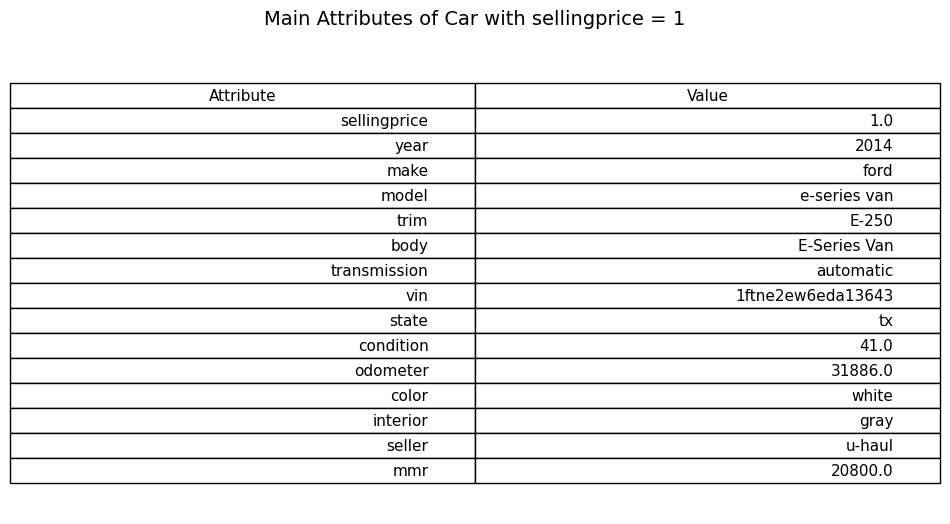

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

cars_price_1 = df[df["sellingprice"] == 1].copy()

if len(cars_price_1) == 0:
    print("No car found with sellingprice = 1")
else:
    cols = [c for c in [
        "sellingprice", "year", "make", "model", "trim", "body",
        "transmission", "vin", "state", "condition", "odometer",
        "color", "interior", "seller", "mmr"
    ] if c in df.columns]

    row = cars_price_1[cols].iloc[0]
    row_df = row.reset_index()
    row_df.columns = ["Attribute", "Value"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")

    table = ax.table(
        cellText=row_df.values,
        colLabels=row_df.columns,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)

    plt.title("Main Attributes of Car with sellingprice = 1", fontsize=14, pad=20)
    plt.show()

In [11]:
# load original dataset again
df_raw = pd.read_csv("/content/drive/MyDrive/output2.csv")

df_raw["sellingprice"] = pd.to_numeric(df_raw["sellingprice"], errors="coerce")

# cars above 128000
cars_above_128k = df_raw[df_raw["sellingprice"] > 128000]

print("Number of cars with price > 128000:", len(cars_above_128k))

# show some examples
print(cars_above_128k[["sellingprice","year","make","model","trim"]].head(20))

Number of cars with price > 128000: 27
       sellingprice  year           make            model  trim
27254      169000.0  2012    rolls-royce            ghost   EWB
27735      169500.0  2012    rolls-royce            ghost  Base
27824      138000.0  2012        ferrari       california  Base
27825      149000.0  2012        ferrari       california  Base
28022      131000.0  2012        ferrari       california  Base
28086      154000.0  2012        ferrari       california  Base
29632      140500.0  2012        bentley  continental gtc  Base
30527      167000.0  2012    rolls-royce            ghost  Base
32114      141000.0  2012        ferrari       california  Base
32186      156000.0  2012        ferrari       california  Base
35202      158000.0  2013        bentley  continental gtc  Base
35514      171500.0  2013    rolls-royce            ghost  Base
36186      139000.0  2013        bentley  continental gtc  Base
38496      130500.0  2013        bentley  continental gtc  Base
4

In [13]:
import pandas as pd

df_raw = pd.read_csv("/content/drive/MyDrive/output2.csv")
df_raw["sellingprice"] = pd.to_numeric(df_raw["sellingprice"], errors="coerce")

cars_below_100 = df_raw[df_raw["sellingprice"] < 100]
cars_above_128000 = df_raw[df_raw["sellingprice"] > 128000]

print("Number of cars below $100:", len(cars_below_100))
print("Number of cars above $128000:", len(cars_above_128000))

Number of cars below $100: 1
Number of cars above $128000: 27
